In [1]:
# LOC Isolation Forest + SHAP — Reduced Feature Set
# Removed: appeal_overturn_rate, mcr_overturn_rate
# 2025: 6 features | 2026: 7 features

from sqlalchemy import create_engine
from snowflake.sqlalchemy import URL
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import shap
import matplotlib.pyplot as plt

c:\Users\knguy139\Documents\Projects\.venv\Lib\site-packages\snowflake\connector\vendored\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(
c:\Users\knguy139\Documents\Projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
engine = create_engine(URL(
    account       = "UHG-UHGDWAAS",
    user          = "KHANG.NGUYEN@UHC.COM",
    authenticator = "externalbrowser",
    role          = "AZU_SDRP_VING_PRD_DEVELOPER_ROLE",
    warehouse     = "VING_PRD_MNR_HCE_DATAINFRA_WH",
    database      = "VING_PRD_TREND_DB",
    schema        = "TMP_1M"
))

In [3]:
df_2025 = pd.read_sql("""
    select
        d.collection as hospital_group
        , a.fin_market
        , '2025' as year
        , count(distinct a.case_id) as case_count
        , count(distinct case when a.initialfulladr_cases = 1 then a.case_id end) as initial_adr_cnt
        , count(distinct case when a.persistentfulladr_cases = 1 then a.case_id end) as persistent_adr_cnt
        , count(distinct case when a.p2p_full_ovtn = 1 then a.case_id end) as p2p_ovrtn_cnt
        , count(distinct case when a.icm_md_reviewed_ind = 1 then a.case_id end) as md_reviewed_cnt
    from tmp_1m.ec_avtar_25_26_3_od as a
    left join tmp_1y.tin_collection as d
        on substr(a.fa_prov_id, 2, 9) = d.tin
    where fin_brand = 'M&R'
        and (
            (ip_type in ('Medical', 'Surgical', 'Transplant')
             and to_varchar(admit_dt_act, 'MM/dd/yyyy') is not null)
            or ip_type in ('LTAC', 'SNF', 'AIR')
        )
        and loc_flag = 1
        and (
            (global_cap = 'NA' and sgr_source_name = 'COSMOS'
             and fin_product_level_3 != 'INSTITUTIONAL' and tfm_include_flag = 1)
            or (sgr_source_name = 'NICE' and nce_tadm_dec_risk_type in ('FFS', 'PHYSICIAN'))
        )
        and d.collection is not null
        and hce_admit_month between '202501' and '202512'
    group by 1,2
    having count(distinct a.case_id) >= 30
""", engine)

df_2026 = pd.read_sql("""
    select
        d.collection as hospital_group
        , a.fin_market
        , '2026' as year
        , count(distinct a.case_id) as case_count
        , count(distinct case when a.initialfulladr_cases = 1 then a.case_id end) as initial_adr_cnt
        , count(distinct case when a.persistentfulladr_cases = 1 then a.case_id end) as persistent_adr_cnt
        , count(distinct case when a.p2p_full_ovtn = 1 then a.case_id end) as p2p_ovrtn_cnt
        , count(distinct case when a.icm_md_reviewed_ind = 1 then a.case_id end) as md_reviewed_cnt
        , count(distinct case when a.member_appeal_ind = 1 then a.case_id end) as member_appeal_cnt
    from tmp_1m.ec_avtar_25_26_3_od as a
    left join tmp_1y.tin_collection as d
        on substr(a.fa_prov_id, 2, 9) = d.tin
    where fin_brand = 'M&R'
        and (
            (ip_type in ('Medical', 'Surgical', 'Transplant')
             and to_varchar(admit_dt_act, 'MM/dd/yyyy') is not null)
            or ip_type in ('LTAC', 'SNF', 'AIR')
        )
        and loc_flag = 1
        and (
            (global_cap = 'NA' and sgr_source_name = 'COSMOS'
             and fin_product_level_3 != 'INSTITUTIONAL' and tfm_include_flag = 1)
            or (sgr_source_name = 'NICE' and nce_tadm_dec_risk_type in ('FFS', 'PHYSICIAN'))
        )
        and d.collection is not null
        and hce_admit_month between '202601' and '202604'
    group by 1,2
    having count(distinct a.case_id) >= 30
""", engine)

print(f"2025: {len(df_2025)} rows | 2026: {len(df_2026)} rows")

 pip install snowflake-connector-python[secure-local-storage]


Initiating login request with your identity provider. Press CTRL+C to abort and try again...
Going to open: https://login.microsoftonline.com/db05faca-c82a-4b9d-b9c5-0f64b6755421/saml2?SAMLRequest=lVLRbtowFP2VyHtO4piQFguoGIwNibYI0lbby%2BTYDnhJ7NR2SPn7OQGk7qGV9mDJss%2B559x77vjurSq9I9dGKDkBUQCBxyVVTMj9BDylS%2F8WeMYSyUipJJ%2BAEzfgbjo2pCprPGvsQW75a8ON9VwhaXD3MQGNllgRIwyWpOIGW4p3s%2Fs1RgHExBiurZMDFwozwmkdrK1xGLZtG7SDQOl9iCCEIRyFDtVBvoB3EvXnGrVWVlFVXilvrqcPJKIQxp2EQziFzYX4VcjzCD5Tyc4gg3%2Bk6cbfPO5S4M2u3c2VNE3F9Y7ro6D8abs%2BGzDOQXPY%2B%2B6wlhDz%2B0ACI1Wbl6TgVFV1Y13NwN3CnLOwVHvhJrVaTEBdCHZzX3zL0xe9Xr%2FOi1PB%2Fgx0kz5mJ7VsSLpEcXxcFd%2FlcbONf1LgPV9zRV2uK2MavpJdmtY9QZT4MPFRkkYIxxEeoGAwSH4Bb%2BHSFJLYnnm13PsIKkG1Miq3SpZC8t4ly%2BAwJ5T49BYRP85GzM9GdOjDPImz5GY4jFEUdpkhcN4b3BvR0%2F%2Bbxjh8z70s4IPLZLXYqFLQk7dUuiL248iiIOpfBPPzHop5RUQ5Y0xzY1x0ZanauebEuj23uuEgnJ5V%2F9306V8%3D&RelayState=ver%3A3-hint%3A260092117886646-ETMsDgAAAZ8D8x2wABRBRVMvQ0JDL1BLQ1M1UGFkZGluZwEAABAAEAm8BGrHoYYFdt0TG%2FrOX4cAAACQk9rk7%2B

In [7]:
# Combine and compute raw rates
df = pd.concat([df_2025, df_2026], ignore_index = True)

df = (
    df
    .assign(
        initial_adr_rate = lambda x: x['initial_adr_cnt'] / x['case_count'],
        persistent_adr_rate = lambda x: x['persistent_adr_cnt'] / x['case_count'],
        md_review_rate = lambda x: x['md_reviewed_cnt'] / x['case_count'],
        p2p_overturn_rate = lambda x: x['p2p_ovrtn_cnt'] / x['initial_adr_cnt'].replace(0, np.nan),
        member_appeal_rate = lambda x: np.where(
            x['year'] == '2026',
            x['member_appeal_cnt'] / x['initial_adr_cnt'].replace(0, np.nan),
            np.nan
        )
    )
)

print(f"Combined rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

Combined rows: 2672
Columns: ['hospital_group', 'fin_market', 'year', 'case_count', 'initial_adr_cnt', 'persistent_adr_cnt', 'p2p_ovrtn_cnt', 'md_reviewed_cnt', 'member_appeal_cnt', 'initial_adr_rate', 'persistent_adr_rate', 'md_review_rate', 'p2p_overturn_rate', 'member_appeal_rate']


In [12]:
# ── Rate configs (reduced: no appeal_overturn, no mcr_overturn)
rate_configs = {
    'initial_adr':    {'num': 'initial_adr_cnt',    'denom': 'case_count'},
    'persistent_adr': {'num': 'persistent_adr_cnt', 'denom': 'case_count'},
    'p2p_overturn':   {'num': 'p2p_ovrtn_cnt',     'denom': 'initial_adr_cnt'},
    'md_review':      {'num': 'md_reviewed_cnt',      'denom': 'case_count'},
}

# Member appeal config (2026 only)
member_appeal_config = {'num': 'MEMBER_APPEAL_CNT', 'denom': 'INITIAL_ADR_CNT'}

print(f"Rate features: {list(rate_configs.keys())} + member_appeal (2026 only)")

Rate features: ['initial_adr', 'persistent_adr', 'p2p_overturn', 'md_review'] + member_appeal (2026 only)


In [13]:
# ── Empirical Bayes: MoM Beta-Binomial k estimation
# Pool both years, full >=30 population (before >=10 ADR filter)

def estimate_k_mom(rates, denoms):
    mask = np.isfinite(rates) & (denoms > 0)
    r = rates[mask]
    n = denoms[mask]
    if len(r) < 10:
        return 50.0
    p_bar = r.mean()
    v_obs = r.var(ddof = 1)
    n_harm = len(n) / np.sum(1.0 / n)
    v_samp = p_bar * (1 - p_bar) / n_harm
    v_signal = v_obs - v_samp
    if v_signal <= 0:
        return 50.0
    alpha = p_bar * (p_bar * (1 - p_bar) / v_signal - 1)
    beta = (1 - p_bar) * (p_bar * (1 - p_bar) / v_signal - 1)
    if alpha <= 0 or beta <= 0:
        return 50.0
    return alpha + beta

# Estimate k for each rate feature (pooled across years)
k_map = {}
for feat, cfg in rate_configs.items():
    rates = df[cfg['num']] / df[cfg['denom']].replace(0, np.nan)
    denoms = df[cfg['denom']]
    k_map[feat] = estimate_k_mom(rates.values, denoms.values)
    print(f"  k_{feat}: {k_map[feat]:.1f}")

# member appeal k (2026 only)
df_26_only = df[df['year'] == '2026'].copy()
rates_ma = df_26_only['member_appeal_cnt'] / df_26_only['initial_adr_cnt'].replace(0, np.nan)
k_map['member_appeal'] = estimate_k_mom(rates_ma.values, df_26_only['initial_adr_cnt'].values)
print(f"  k_member_appeal: {k_map['member_appeal']:.1f}")

print(f"\nFinal k_map: {k_map}")

  k_initial_adr: 8.3
  k_persistent_adr: 15.1
  k_p2p_overturn: 8.7
  k_md_review: 2.0
  k_member_appeal: 5.1

Final k_map: {'initial_adr': np.float64(8.334741837934015), 'persistent_adr': np.float64(15.142247673268791), 'p2p_overturn': np.float64(8.720736903387595), 'md_review': np.float64(2.0044795615958404), 'member_appeal': np.float64(5.064466148157266)}


In [14]:
# ── Apply Empirical Bayes shrinkage
# Global rates from full >=30 population (before ADR filter)

def compute_global_rate(df_full, num_col, denom_col):
    return df_full[num_col].sum() / df_full[denom_col].sum()

# global rates
global_rates = {}
for feat, cfg in rate_configs.items():
    global_rates[feat] = compute_global_rate(df, cfg['num'], cfg['denom'])
    print(f"  global_{feat}: {global_rates[feat]:.4f}")

# member appeal global (2026 only)
global_rates['member_appeal'] = compute_global_rate(df_26_only, 'member_appeal_cnt', 'initial_adr_cnt')
print(f"  global_member_appeal: {global_rates['member_appeal']:.4f}")

def shrink(num, denom, k, p_global):
    return (num + k * p_global) / (denom + k)

# apply >=10 adr filter for if input
df_model = df[df['initial_adr_cnt'] >= 10].copy()
print(f"\nafter adr>=10 filter: {len(df_model)} rows")

# shrink each feature
for feat, cfg in rate_configs.items():
    df_model[f"{feat}_adj_rate"] = shrink(
        df_model[cfg['num']], df_model[cfg['denom']],
        k_map[feat], global_rates[feat]
    )

# member appeal (2026 only)
df_model['member_appeal_adj_rate'] = np.where(
    df_model['year'] == '2026',
    shrink(
        df_model['member_appeal_cnt'], df_model['initial_adr_cnt'],
        k_map['member_appeal'], global_rates['member_appeal']
    ),
    np.nan
)

# log volumes
df_model = (
    df_model
    .assign(
        log_case_count = lambda x: np.log1p(x['case_count']),
        log_initial_adr_cnt = lambda x: np.log1p(x['initial_adr_cnt'])
    )
)

print(f"shrinkage applied. model features ready.")

  global_initial_adr: 0.2634
  global_persistent_adr: 0.1384
  global_p2p_overturn: 0.3742
  global_md_review: 0.5989
  global_member_appeal: 0.0336

after adr>=10 filter: 2016 rows
shrinkage applied. model features ready.


In [15]:
# ── Isolation Forest — separate per-year models
from sklearn.ensemble import IsolationForest

# Feature sets (REDUCED: no appeal_overturn, no mcr_overturn)
iso_kpi_6 = [
    'log_case_count', 'log_initial_adr_cnt',
    'initial_adr_adj_rate', 'persistent_adr_adj_rate',
    'p2p_overturn_adj_rate', 'md_review_adj_rate'
]
iso_kpi_7 = iso_kpi_6 + ['member_appeal_adj_rate']

print(f"2025 features ({len(iso_kpi_6)}): {iso_kpi_6}")
print(f"2026 features ({len(iso_kpi_7)}): {iso_kpi_7}")

# Split by year
df_25m = df_model[df_model['year'] == '2025'].copy()
df_26m = df_model[df_model['year'] == '2026'].copy()
print(f"\n2025 model input: {len(df_25m)} hospitals")
print(f"2026 model input: {len(df_26m)} hospitals")

# Fit IF models
if_25 = IsolationForest(n_estimators = 300, contamination = 'auto', random_state = 42)
if_25.fit(df_25m[iso_kpi_6])

if_26 = IsolationForest(n_estimators = 300, contamination = 'auto', random_state = 42)
if_26.fit(df_26m[iso_kpi_7])

# Score
df_25m['anomaly_score'] = if_25.decision_function(df_25m[iso_kpi_6])
df_26m['anomaly_score'] = if_26.decision_function(df_26m[iso_kpi_7])

# Threshold: 2.5th percentile per year
thresh_25 = np.percentile(df_25m['anomaly_score'], 2.5)
thresh_26 = np.percentile(df_26m['anomaly_score'], 2.5)
df_25m['anomaly_flag'] = df_25m['anomaly_score'] <= thresh_25
df_26m['anomaly_flag'] = df_26m['anomaly_score'] <= thresh_26

print(f"\n2025 threshold: {thresh_25:.4f}, flagged: {df_25m['anomaly_flag'].sum()}")
print(f"2026 threshold: {thresh_26:.4f}, flagged: {df_26m['anomaly_flag'].sum()}")

2025 features (6): ['log_case_count', 'log_initial_adr_cnt', 'initial_adr_adj_rate', 'persistent_adr_adj_rate', 'p2p_overturn_adj_rate', 'md_review_adj_rate']
2026 features (7): ['log_case_count', 'log_initial_adr_cnt', 'initial_adr_adj_rate', 'persistent_adr_adj_rate', 'p2p_overturn_adj_rate', 'md_review_adj_rate', 'member_appeal_adj_rate']

2025 model input: 1226 hospitals
2026 model input: 790 hospitals

2025 threshold: -0.0911, flagged: 31
2026 threshold: -0.0769, flagged: 20


In [16]:
# ── Bootstrap stability (200 iterations per year)
from sklearn.utils import resample

def bootstrap_flags(df_year, features, n_iter = 200, pct = 2.5, random_state = 42):
    rng = np.random.RandomState(random_state)
    n = len(df_year)
    flag_counts = np.zeros(n)
    for i in range(n_iter):
        idx = rng.choice(n, size = n, replace = True)
        X_boot = df_year[features].iloc[idx]
        model = IsolationForest(n_estimators = 300, contamination = 'auto', random_state = i)
        model.fit(X_boot)
        scores = model.decision_function(df_year[features])
        threshold = np.percentile(scores, pct)
        flag_counts += (scores <= threshold).astype(int)
    return flag_counts / n_iter

print("Bootstrap 2025 (200x)...")
df_25m['bootstrap_flag_pct'] = bootstrap_flags(df_25m, iso_kpi_6)
print("Bootstrap 2026 (200x)...")
df_26m['bootstrap_flag_pct'] = bootstrap_flags(df_26m, iso_kpi_7)

# Consensus: flag if >= 50%
df_25m['consensus_flag'] = df_25m['bootstrap_flag_pct'] >= 0.50
df_26m['consensus_flag'] = df_26m['bootstrap_flag_pct'] >= 0.50

print(f"\n2025 consensus flags: {df_25m['consensus_flag'].sum()}")
print(f"2026 consensus flags: {df_26m['consensus_flag'].sum()}")

Bootstrap 2025 (200x)...
Bootstrap 2026 (200x)...

2025 consensus flags: 31
2026 consensus flags: 19


In [17]:
# ── SHAP attribution
import shap

explainer_25 = shap.TreeExplainer(if_25)
explainer_26 = shap.TreeExplainer(if_26)

shap_25 = explainer_25.shap_values(df_25m[iso_kpi_6])
shap_26 = explainer_26.shap_values(df_26m[iso_kpi_7])

# Assign primary driver (most negative SHAP = strongest anomaly push)
def get_driver(shap_vals, features, df_year):
    min_idx = np.argmin(shap_vals, axis = 1)
    drivers = [features[i] for i in min_idx]
    medians = {f: df_year[f].median() for f in features}
    directions = [
        'high' if df_year[feat].iloc[row] > medians[feat] else 'low'
        for row, feat in enumerate(drivers)
    ]
    return drivers, directions

df_25m['shap_driver'], df_25m['driver_direction'] = get_driver(shap_25, iso_kpi_6, df_25m)
df_26m['shap_driver'], df_26m['driver_direction'] = get_driver(shap_26, iso_kpi_7, df_26m)

print("SHAP attribution complete.")
print(f"\n2025 driver distribution:")
print(df_25m[df_25m['consensus_flag']]['shap_driver'].value_counts())
print(f"\n2026 driver distribution:")
print(df_26m[df_26m['consensus_flag']]['shap_driver'].value_counts())

SHAP attribution complete.

2025 driver distribution:
shap_driver
md_review_adj_rate         16
initial_adr_adj_rate        5
persistent_adr_adj_rate     4
log_initial_adr_cnt         3
p2p_overturn_adj_rate       2
log_case_count              1
Name: count, dtype: int64

2026 driver distribution:
shap_driver
member_appeal_adj_rate     9
md_review_adj_rate         8
persistent_adr_adj_rate    2
Name: count, dtype: int64


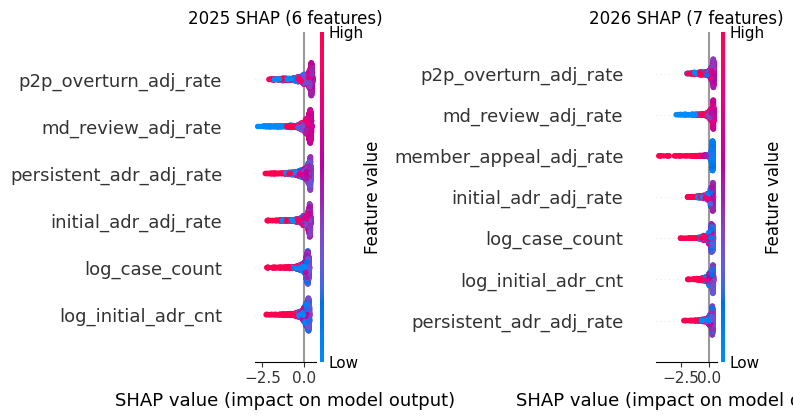

In [18]:
# ── SHAP summary plots
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize = (16, 6))

plt.sca(axes[0])
shap.summary_plot(shap_25, df_25m[iso_kpi_6], feature_names = iso_kpi_6, show = False)
axes[0].set_title('2025 SHAP (6 features)')

plt.sca(axes[1])
shap.summary_plot(shap_26, df_26m[iso_kpi_7], feature_names = iso_kpi_7, show = False)
axes[1].set_title('2026 SHAP (7 features)')

plt.tight_layout()
plt.show()

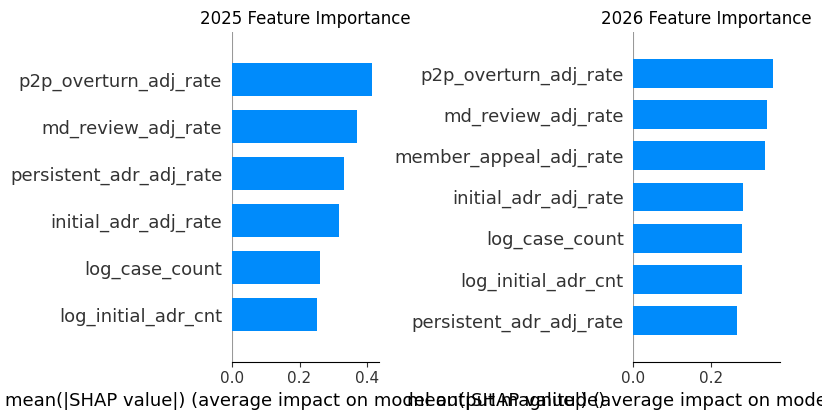

In [19]:
# ── SHAP bar plot (mean absolute SHAP values)
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

plt.sca(axes[0])
shap.summary_plot(shap_25, df_25m[iso_kpi_6], feature_names = iso_kpi_6, plot_type = 'bar', show = False)
axes[0].set_title('2025 Feature Importance')

plt.sca(axes[1])
shap.summary_plot(shap_26, df_26m[iso_kpi_7], feature_names = iso_kpi_7, plot_type = 'bar', show = False)
axes[1].set_title('2026 Feature Importance')

plt.tight_layout()
plt.show()

In [20]:
# ── Build output table
DRIVER_RENAME = {
    'md_review_adj_rate': 'MD Escalation Rate',
    'member_appeal_adj_rate': 'Member Appeal Rate',
    'persistent_adr_adj_rate': 'Persistent ADR Rate',
    'initial_adr_adj_rate': 'Initial ADR Rate',
    'p2p_overturn_adj_rate': 'P2P Overturn Rate',
    'log_case_count': 'Case Count',
    'log_initial_adr_cnt': 'Initial ADR Count',
}

def build_output(df_year, features):
    out = df_year.copy()
    out['driver'] = out['shap_driver'].map(DRIVER_RENAME).fillna(out['shap_driver'])
    out['direction'] = out['driver_direction']
    out['reason'] = out['driver'] + ' (' + out['direction'] + ')'

    # Vectorized driver value lookup
    out['driver_value'] = [
        out.loc[idx, out.loc[idx, 'shap_driver']] for idx in out.index
    ]
    out['driver_adj_median'] = out['shap_driver'].map(
        {f: out[f].median() for f in features}
    )
    out['driver_dev_pct'] = np.where(
        out['driver_adj_median'] != 0,
        (out['driver_value'] - out['driver_adj_median']) / out['driver_adj_median'],
        0
    )
    out['anomaly_rank'] = out['anomaly_score'].rank(method = 'dense').astype(int)
    out['percentile_rank'] = out['anomaly_score'].rank(pct = True)
    return out

out_25 = build_output(df_25m, iso_kpi_6)
out_26 = build_output(df_26m, iso_kpi_7)

df_out = pd.concat([out_25, out_26], ignore_index = True)

# Filter to consensus flags only for final output
df_final = df_out[df_out['consensus_flag']].copy()
print(f"Final output: {len(df_final)} flagged hospitals")
print(f"  2025: {len(df_final[df_final['year'] == '2025'])}")
print(f"  2026: {len(df_final[df_final['year'] == '2026'])}")

Final output: 50 flagged hospitals
  2025: 31
  2026: 19


In [24]:
df_final

,hospital_group,fin_market,year,case_count,initial_adr_cnt,persistent_adr_cnt,p2p_ovrtn_cnt,md_reviewed_cnt,member_appeal_cnt,initial_adr_rate,...,shap_driver,driver_direction,driver,direction,reason,driver_value,driver_adj_median,driver_dev_pct,anomaly_rank,percentile_rank
198,Alta Hospital System (Prospect Holdings),CA-S,2025,46,33,17,0,34,NaN,0.717391,...,initial_adr_adj_rate,high,Initial ADR Rate,high,Initial ADR Rate (high),0.647744,0.289453,1.237820,21,0.017129
219,Novant Health System,NC,2025,15911,5248,3695,349,12295,NaN,0.329835,...,log_initial_adr_cnt,high,Initial ADR Count,high,Initial ADR Count (high),8.565793,4.189655,1.044510,10,0.008157
242,Ascension MI,MI,2025,1330,93,65,0,154,NaN,0.069925,...,md_review_adj_rate,low,MD Escalation Rate,low,MD Escalation Rate (low),0.116517,0.701510,-0.833906,3,0.002447
267,VALLEY VIEW HOSPITAL ASSOCIATION,CO,2025,244,16,17,0,0,NaN,0.065574,...,md_review_adj_rate,low,MD Escalation Rate,low,MD Escalation Rate (low),0.004880,0.701510,-0.993043,14,0.011419
305,PHC-FT MOHAVE,AZ,2025,86,57,29,4,54,NaN,0.662791,...,initial_adr_adj_rate,high,Initial ADR Rate,high,Initial ADR Rate (high),0.627500,0.289453,1.167880,35,0.028548
338,Hennepin Healthcare System,MN,2025,531,30,15,11,44,NaN,0.056497,...,md_review_adj_rate,low,MD Escalation Rate,low,MD Escalation Rate (low),0.084803,0.701510,-0.879113,25,0.020392
425,Carle Foundation,IL,2025,750,25,13,11,51,NaN,0.033333,...,md_review_adj_rate,low,MD Escalation Rate,low,MD Escalation Rate (low),0.069415,0.701510,-0.901049,15,0.012235
451,WESTCHESTER GENERAL HOSPITAL,FL,2025,114,79,54,5,73,NaN,0.692982,...,initial_adr_adj_rate,high,Initial ADR Rate,high,Initial ADR Rate (high),0.663712,0.289453,1.292985,6,0.004894
466,HCA INC,FL,2025,32260,14062,7042,6303,23194,NaN,0.435896,...,log_initial_adr_cnt,high,Initial ADR Count,high,Initial ADR Count (high),9.551303,4.189655,1.279735,16,0.013051
537,Froedtert,WI,2025,8223,2264,1053,0,5091,NaN,0.275325,...,p2p_overturn_adj_rate,low,P2P Overturn Rate,low,P2P Overturn Rate (low),0.001436,0.368643,-0.996105,24,0.019576


=== Top 5 Flagged — 2025 ===

ADVOCATE HEALTH & HOSPITALS IL — IL (2025)


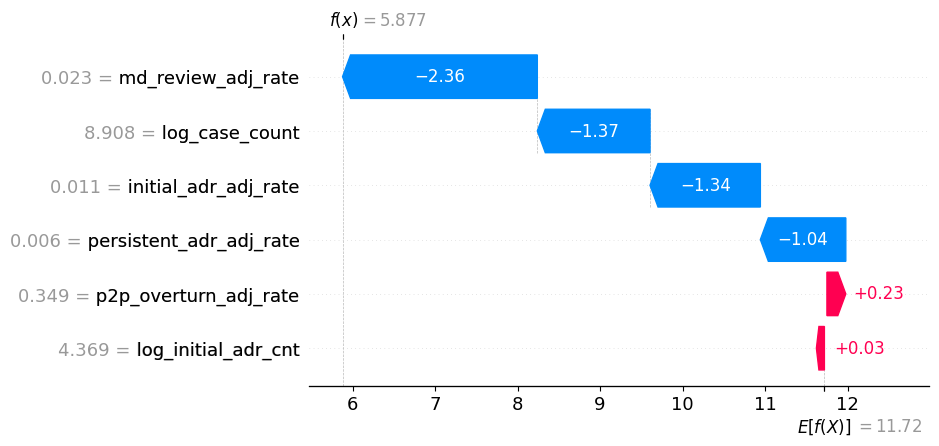


HEALTH CARE AUTHORITY OF THE CITY OF ANN — AL (2025)


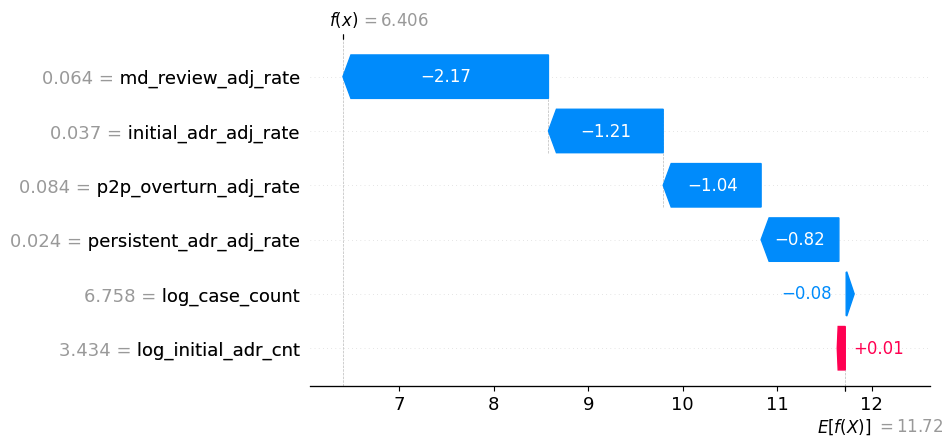


Ascension MI — MI (2025)


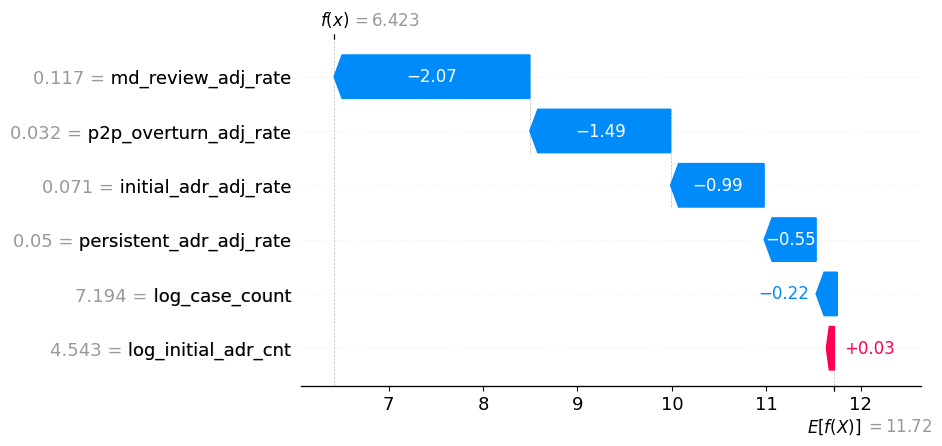


SURGICAL CARE AFFILIATES — IL (2025)


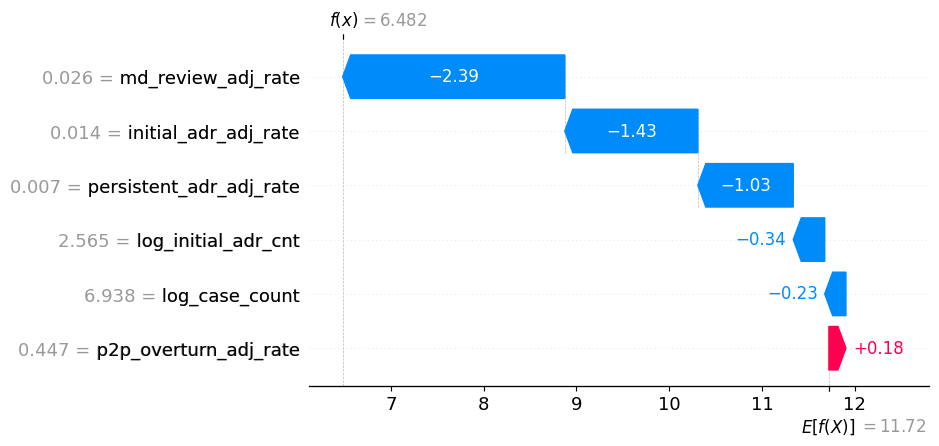


Steward — FL (2025)


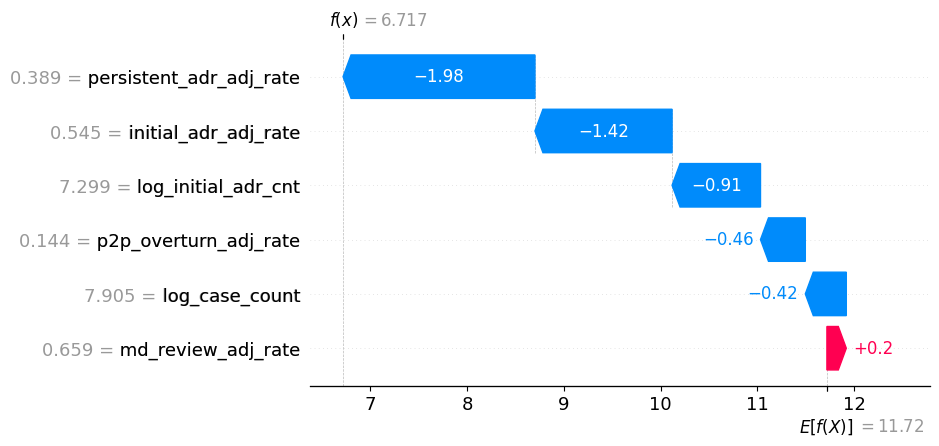


=== Top 5 Flagged — 2026 ===

Atrium Health System — NC (2026)


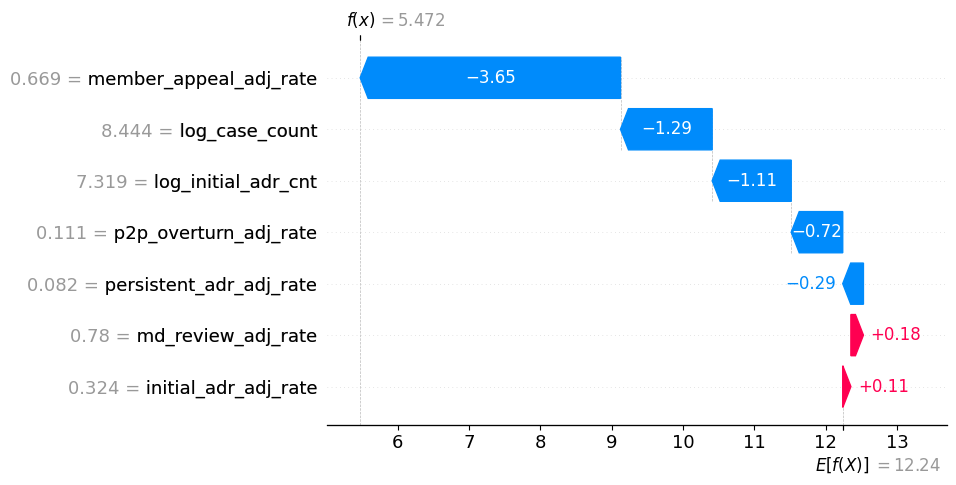


ADVOCATE HEALTH & HOSPITALS IL — IL (2026)


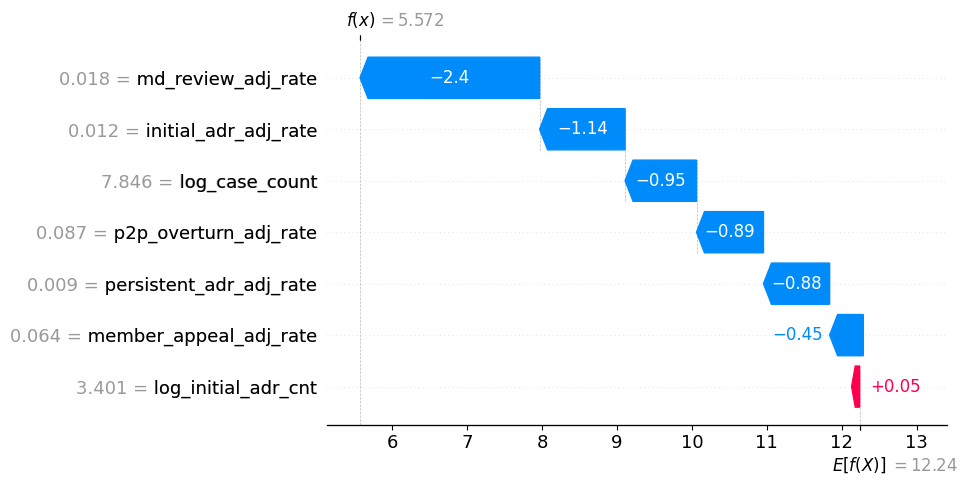


NORTH CAROLINA BAPTIST HOSPITAL SYSTEM — NC (2026)


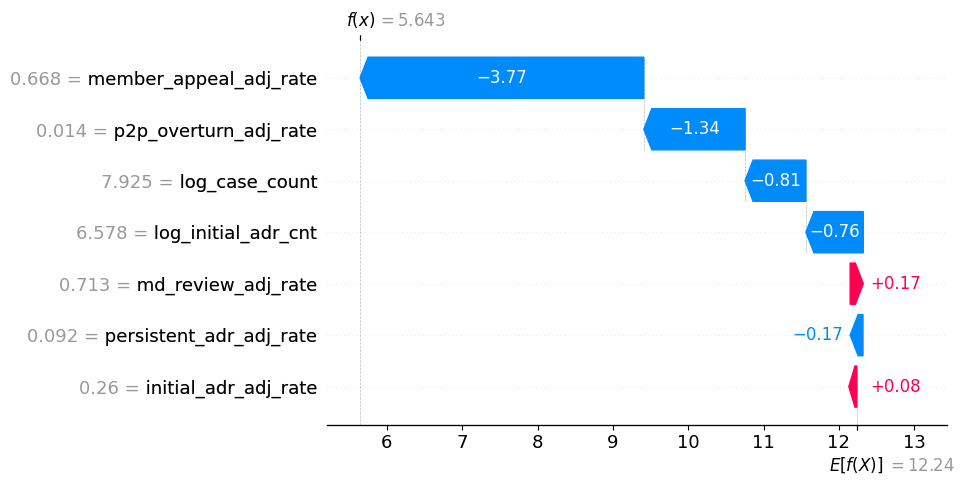


WESTCHESTER GENERAL HOSPITAL — FL (2026)


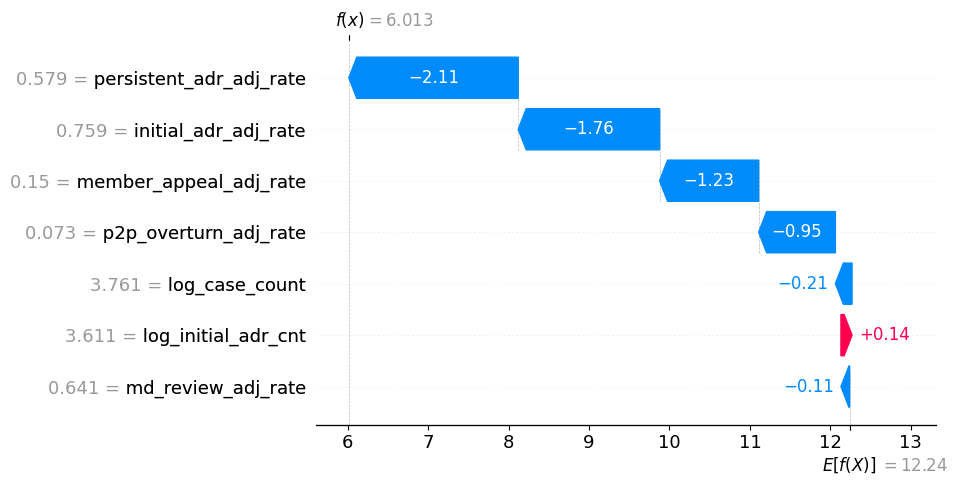


HUGH CHATHAM MEMORIAL HOSPITAL — NC (2026)


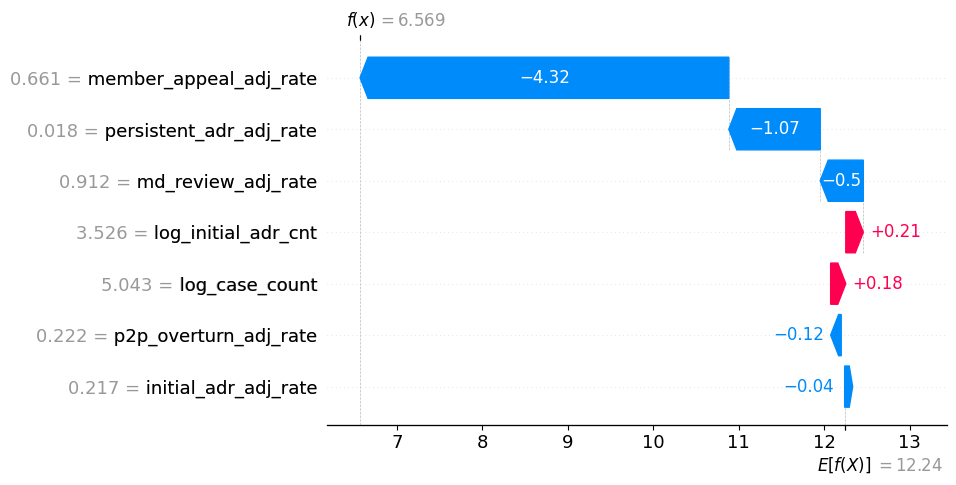

In [26]:
# ── Waterfall plots for top flagged hospitals
def plot_waterfall(shap_vals, features, df_year, year, top_n = 5):
    flagged = df_year[df_year['consensus_flag']].nsmallest(top_n, 'anomaly_score')
    for idx in flagged.index:
        pos = df_year.index.get_loc(idx)
        hospital = df_year.loc[idx, 'hospital_group']
        market = df_year.loc[idx, 'fin_market']
        print(f"\n{hospital} — {market} ({year})")
        ev = explainer_25.expected_value if year == '2025' else explainer_26.expected_value
        base_val = float(ev[0]) if hasattr(ev, '__len__') else float(ev)
        shap.waterfall_plot(
            shap.Explanation(
                values = shap_vals[pos],
                base_values = base_val,
                feature_names = features,
                data = df_year[features].iloc[pos].values
            ),
            show = True
        )

print("=== Top 5 Flagged — 2025 ===")
plot_waterfall(shap_25, iso_kpi_6, df_25m, '2025')
print("\n=== Top 5 Flagged — 2026 ===")
plot_waterfall(shap_26, iso_kpi_7, df_26m, '2026')

In [ ]:
# ── Write to Snowflake (via SQLAlchemy)

output_cols = [
    'hospital_group', 'fin_market', 'year',
    'case_count', 'initial_adr_cnt', 'persistent_adr_cnt', 'p2p_ovrtn_cnt', 'md_reviewed_cnt',
    'initial_adr_rate', 'persistent_adr_rate', 'p2p_overturn_rate', 'md_review_rate',
    'initial_adr_adj_rate', 'persistent_adr_adj_rate', 'p2p_overturn_adj_rate', 'md_review_adj_rate',
    'log_case_count', 'log_initial_adr_cnt',
    'anomaly_score', 'anomaly_rank', 'percentile_rank', 'anomaly_flag',
    'bootstrap_flag_pct', 'consensus_flag',
    'driver', 'direction', 'reason', 'driver_value', 'driver_adj_median', 'driver_dev_pct'
]

# Add member_appeal cols where present
if 'member_appeal_cnt' in df_final.columns:
    output_cols.insert(output_cols.index('md_reviewed_cnt') + 1, 'member_appeal_cnt')
    output_cols.insert(output_cols.index('md_review_rate') + 1, 'member_appeal_rate')
    output_cols.insert(output_cols.index('md_review_adj_rate') + 1, 'member_appeal_adj_rate')

df_write = df_final[output_cols].copy()

table_name = 'KND_LOC_IF_REDUCED_2025_2026'
df_write.to_sql(table_name, engine, schema = 'TMP_1M', if_exists = 'replace', index = False)
print(f"Written to TMP_1M.{table_name}: {len(df_write)} rows")

In [ ]:
# ── Summary comparison placeholder
# After running, compare flag sets with production table:
# VING_PRD_TREND_DB.TMP_1M.KN_LOC_IF_OUTLIER_HOSPITALS_MNR_2025_2026

print("Done. Compare reduced flag set against production:")
print("  - How many hospitals overlap?")
print("  - Which hospitals are new flags?")
print("  - Which hospitals dropped off?")
print("  - Does cross-year consistency improve?")